In [1]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import gala
import astropy.units as u
from astropy.table import Table

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import animation
from matplotlib.animation import FuncAnimation

import scipy
from scipy import stats
from scipy.interpolate import InterpolatedUnivariateSpline, UnivariateSpline
from scipy.optimize import curve_fit

import sys, importlib
sys.path.append('../code/')
import os
from df_helpers import *

In [2]:
%matplotlib inline
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['ytick.minor.width'] = 1.0

plt.rcParams.update({
    "lines.color": "white",
    "patch.edgecolor": "white",
    "text.color": "black",
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white"})

In [4]:
## Code to import data

data = ...

Loading Actions...


In [83]:
## Code snippet ending with defining the LaguerreSnails object

...
...
LS = LaguerreSnails(...)

## Pitch angle and Phase

In [84]:
print('Calculating distribution function...')
LS.get_coeffs()
LS.create_df(n_maxs)
print('Making Spiral Residual in Data...')
LS.make_spiral_residual()
print('Making Spiral Reconstruction...')
LS.make_spiral_recon(n_maxs)

Calculating distribution function...
Making Spiral Residual in Data...
Making Spiral Reconstruction...


### Defining the Region for Pitch and Phase Angle Calculation

Inner limit: LS.a (exponential scale of $J_z$)

Outer limit: Where the average number count in each $J_z-\theta_z$ bin drops under 1. This would be where there are <96 stars in a bin of J_z. 

### Getting Pitch and Phase Angles

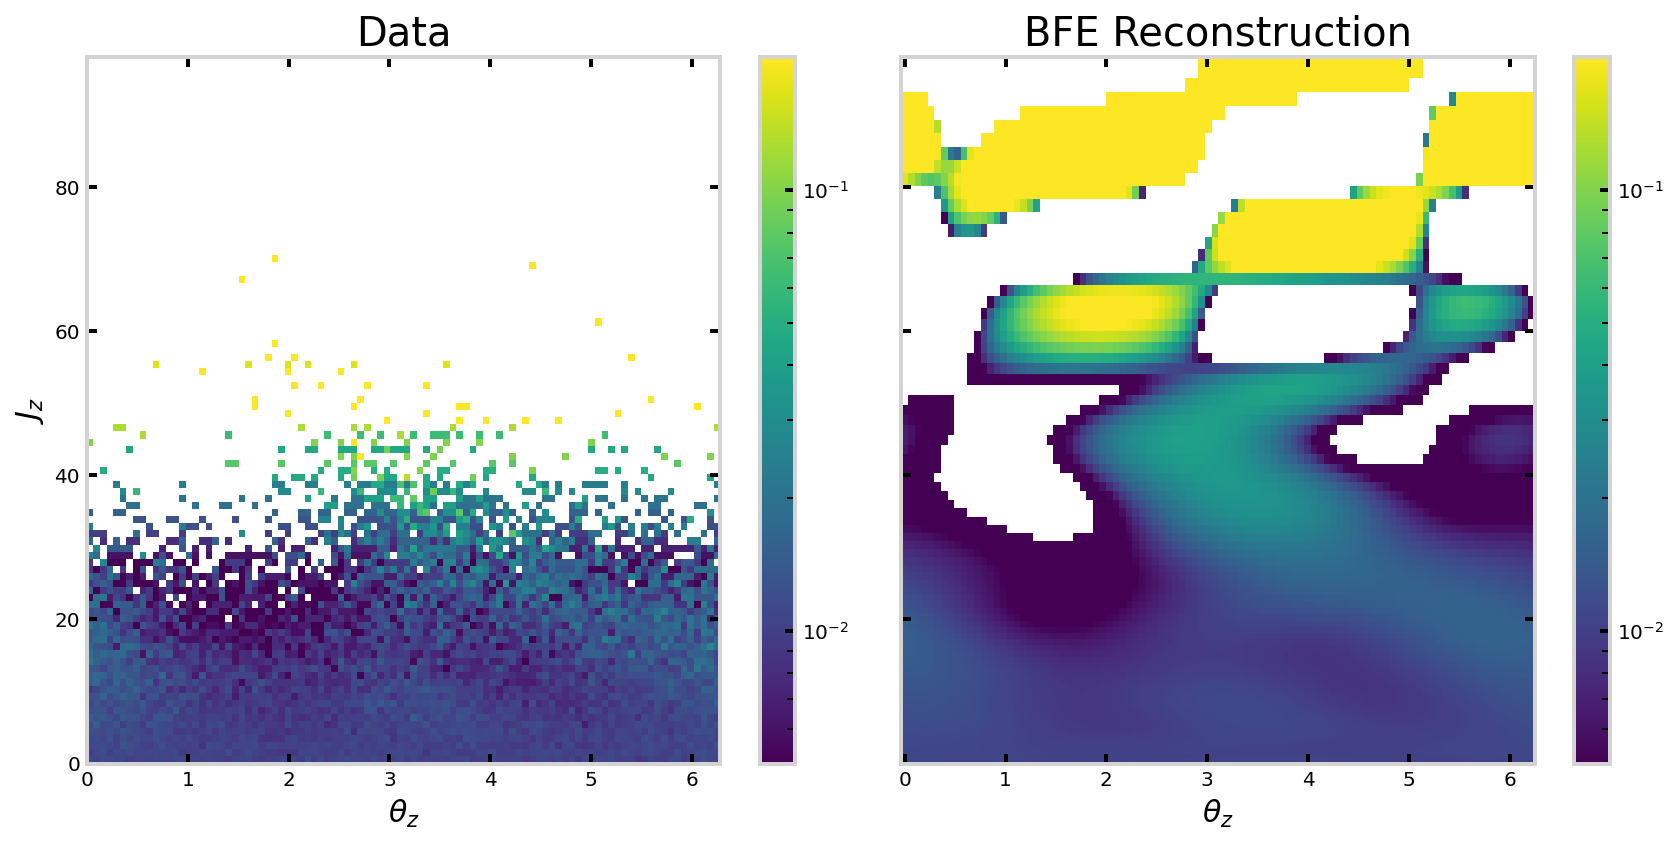

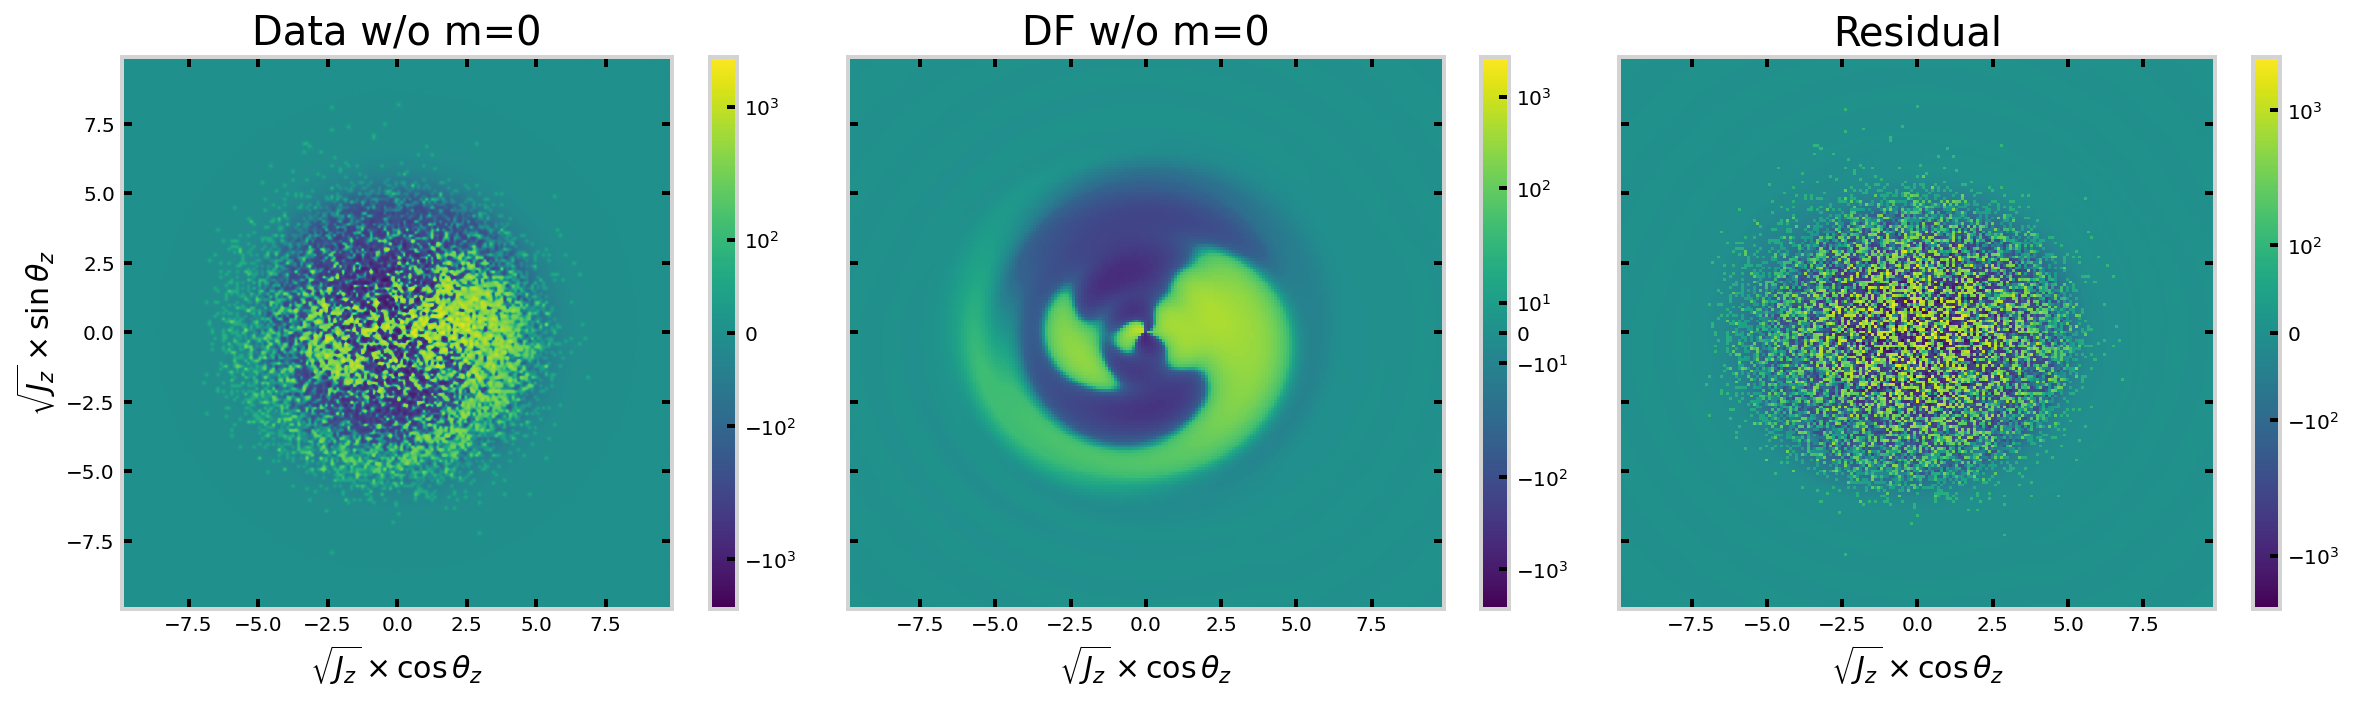

In [86]:
%matplotlib inline
fig = LS.plot_data_recon()
fig = LS.summary_plots()

Using the coefficients of the basis function expansion for a spiral with a given number of arms (in the case below a one-armed spiral), we can find the $\theta_z$ value with the highest particle density at each $J_z$.

In [87]:
m=1 # for a one-armed spiral
ns_ = np.arange(n_maxs[m])

def find_peak(thetaz, Jz, m, ns, LS):
    '''
    The construction of this function will allow me to fit for the thetaz 
    value that gives the peak density using scipy.optimize.fmin below
    '''
    C = np.sum(LS.coeffs[m,n] * disk_lag(n,Jz,LS.a) for n in ns)
    real = (C*np.exp(-1j*m*thetaz)).real
    return -real # so that I can use scipy.optimize.fmin


peaks_=[]
for i in range(len(Jz_grid)):
    act = Jz_grid[i]
    new_peak = scipy.optimize.fmin(find_peak, x0=np.pi/m, args=(act, m, ns_, LS), disp=False)
    peaks_ = np.append(peaks_, new_peak)
peaks = 1/m*np.unwrap(m*peaks_) # necessary for fitting (see what this does in the plots below and in documentation)

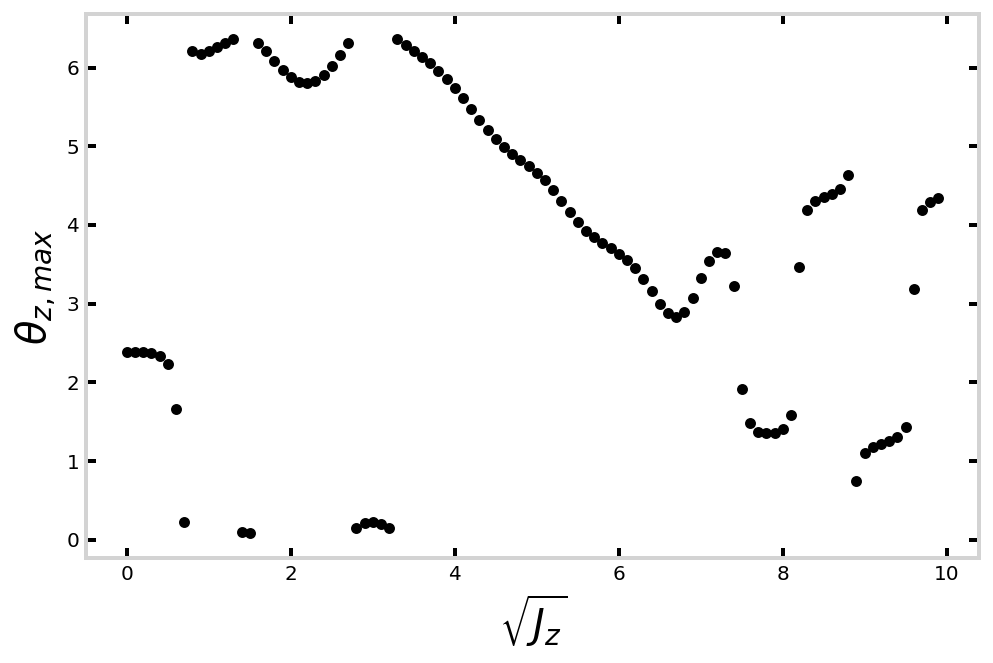

In [88]:
## plot the theta_z value for each J_z with the highest density in the reconstruction

plt.figure(figsize=(8, 5))
plt.scatter(np.sqrt(Jz_grid), peaks_, s=20, c='k')
plt.xlabel(r'$\sqrt{J_z}$', fontsize=20)
plt.ylabel(r'$\theta_{z,max}$', fontsize=20)
plt.show()

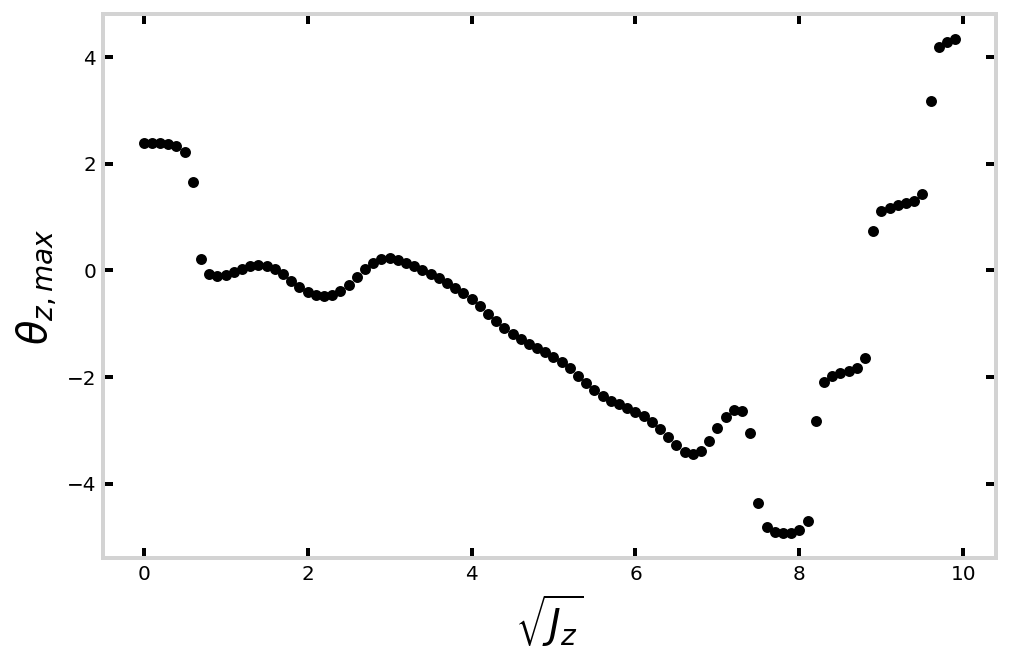

In [89]:
# unwrapped version which is more continuous
plt.figure(figsize=(8, 5))
plt.scatter(np.sqrt(Jz_grid), peaks, s=20, c='k')
plt.xlabel(r'$\sqrt{J_z}$', fontsize=20)
plt.ylabel(r'$\theta_{z,max}$', fontsize=20)
plt.show()

In get_pitch_phase_angles, we are fitting a curve to these points in the region where they seem reasonable. I.e. we cut out the inner part (this is why we start at LS.a) and the outer part (where we don't have enough stars and the reconstruction is meaningless).

So we can plot the fit against the original points. I rewrite part of the function here because we need to output the raw phase angle (before converting it to between 0 and 2$\pi$ to make this plot visually useful.

In [91]:
def pitch_phase(LS, peaks):

    spl = InterpolatedUnivariateSpline(np.sqrt(LS.Jz_grid), peaks)
    dspl = spl.derivative(n=1)

    hist, _ = np.histogram(np.sqrt(LS.sel.jz), bins=len(LS.Jz_grid), range=[0,np.max(np.sqrt(LS.Jz_grid))])
    inner = np.argmin(np.abs(LS.Jz_grid - LS.a))
    if np.min(hist) >= len(LS.thetaz_grid):
        outer = len(LS.Jz_grid)-1
    else:
        # outer = np.where(hist < len(self.thetaz_grid))[0][0]
        low_numbers = np.where(hist < len(self.thetaz_grid))[0]
        if len(low_numbers[low_numbers > inner]) > 0:
            outer = np.min(low_numbers[low_numbers > inner])
        else:
            outer=inner

    cut_jz = np.sqrt(LS.Jz_grid[inner:outer])
    cut_peaks = peaks[inner:outer]

    ind_for_fit = dspl(cut_jz)<0

    
    if len(np.where(ind_for_fit)[0]) >= (outer-inner)/2:  #must be negative pitch angle at least half the time
        self.pitch_phase_flag = 0
    else: #if the calculations are not well defined, do them anyway but flag the region    
        self.pitch_phase_flag = 1 
        
    def get_values(cut_jz, pitch_angle, phase_angle): # this is the functional form of a logarithmic spiral
            return 1/np.tan(pitch_angle) * np.log(cut_jz) + phase_angle

    try: 
        pitch_angle, phase = curve_fit(get_values, cut_jz[ind_for_fit], cut_peaks[ind_for_fit], 
                                        p0=[-0.1, 20], bounds=[[-np.pi/2, -100], [0, 1000]], 
                                        loss='cauchy')[0]
        phase_angle = phase % (2*np.pi)
        print(pitch_angle, phase_angle)
    except: # if calculation doesn't work, set pitch angle=0 and phase angle=pi
        pitch_angle = 0
        phase_angle = np.pi # you could change this to np.nan instead of just a number because it might mess with your plots otherwise

        pitch_phase_flag = 2
    
    return pitch_angle, phase, flag, cut_jz #output necessary for plotting

In [ ]:
pitch_angle, phase, flag, cut_jz = pitch_phase(LS, peaks)

fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharex=True)
ax.scatter(np.sqrt(Jz_grid), peaks)
ax.set_ylabel(r'$\theta_{z,max}$', fontsize=15)
ax.plot(cut_jz, np.log(cut_jz) / np.tan(pitch_angle) + phase)
plt.show()

How to evaluate if this is good: by eye, we as researchers can tell which regions are part of the actual spiral and which aren't. The form of the function we are fitting is fixed so it isn't meant to be a perfect (or even good) fit to all the points in the arbitrarily chosen region. As long as the slope of the line does match the part which we think is where the spiral exists, then we can trust the pitch angle. $\textbf{Happy to take a look at some examples with you if this doesn't make sense!}$

## Visualizing pitch angles

I want to write a function that takes in a pitch angle and allows us to visualize what that would look like in the spiral space. Otherwise it's difficult to know what $\psi = 0.1$ looks like vs $\psi=0.3$ or $\psi=0.03$

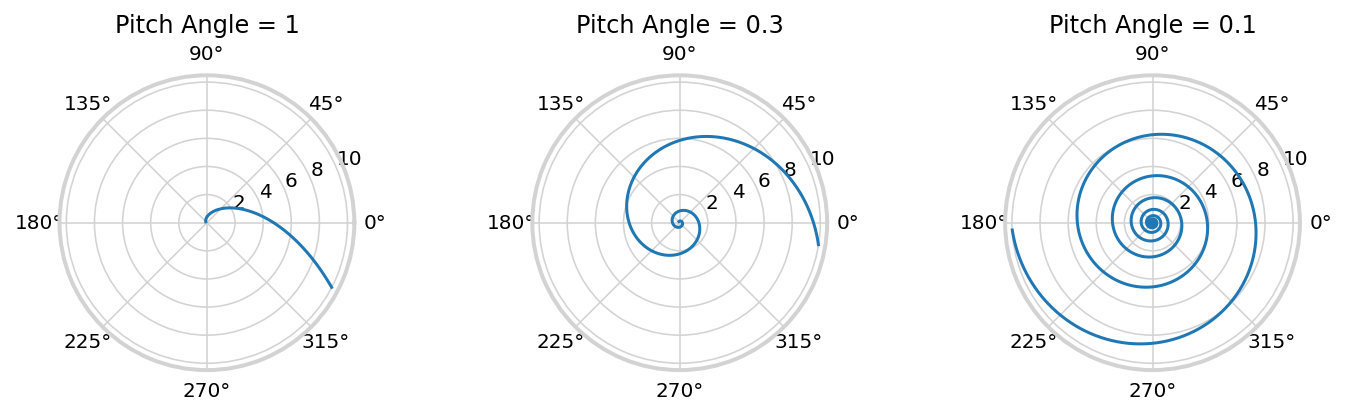

In [11]:
def pitch_ang_vis(pa, ax):
    root_jz = np.arange(0.1, 10, 0.01)
    log_spiral = 1/np.tan(pa) * np.log(root_jz) + 1
    thetaz_max = log_spiral % (2*np.pi) # probably don't need this
    
    ax.plot(log_spiral, root_jz)
    ax.set_title('Pitch Angle = {}'.format(-pa))

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(10, 3), subplot_kw={'projection':'polar'})

pitch_ang_vis(-0.1, ax3)
pitch_ang_vis(-0.3, ax2)
pitch_ang_vis(-1, ax1)
fig.tight_layout()
plt.savefig('/mnt/home/ktavangar/projects/MSSA_Snails/figures/pitch_angle_vis.pdf')